# CardioKB: Link Prediction on a Biomedical Knowledge Graph

This notebook demonstrates link prediction on the CardioKB Neo4j knowledge graph (see graph statistics below). 

To implement this:

1. Connect to the Neo4j instance and query live graph statistics
2. Assign **normalized edge weights** to all relationships (source-specific normalization for scored edges, flat weights for binary edges)
3. Run **Common Neighbors** and **Weighted Adamic-Adar** link prediction for the cardiac ion channel gene *SCN5A* (proof of concept)
4. Evaluate whether known disease associations (example being Long QT Syndrome) surface in the predictions
5. Output a ranked table of top predicted gene–disease links for **atrial fibrillation**

## 1. Setup and Neo4j Connection

First, read the credentials from the project `.env` file and open a Neo4j driver session.

In [1]:
import os
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 60)

# -- Load .env credentials (never printed) --
env_path = Path("../.env")
env_vars = {}
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, v = line.split("=", 1)
            env_vars[k.strip()] = v.strip()

NEO4J_URI = env_vars.get("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = env_vars.get("NEO4J_USERNAME", "neo4j")
NEO4J_PASS = env_vars.get("NEO4J_PASSWORD", "")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))
driver.verify_connectivity()
print("Connected to Neo4j.")

Connected to Neo4j.


In [2]:
def run_query(cypher: str, **params) -> pd.DataFrame:
    """Execute a Cypher query and return results as a DataFrame."""
    with driver.session() as session:
        result = session.run(cypher, **params)
        records = [record.data() for record in result]
    return pd.DataFrame(records) if records else pd.DataFrame()

## 2. Basic Graph Statistics

Before any prediction work, see what's in the graph: node counts by label and relationship counts by type.

In [ ]:
# Node counts by label (no APOC required)
with driver.session() as session:
    labels = [r["l"][0] for r in session.run("MATCH (n) RETURN DISTINCT labels(n) AS l") if r["l"]]

rows = []
for label in labels:
    cnt = run_query(f"MATCH (n:`{label}`) RETURN count(n) AS Count")
    rows.append({"NodeType": label, "Count": int(cnt["Count"].iloc[0])})

node_counts = pd.DataFrame(rows).sort_values("Count", ascending=False).reset_index(drop=True)

print(f"Total node labels: {len(node_counts)}")
print(f"Total nodes:       {node_counts['Count'].sum():,}")
print()
print(node_counts.to_string(index=False))

In [ ]:
# Relationship counts by type (no APOC required)
with driver.session() as session:
    rel_types = [r["rt"] for r in session.run("MATCH ()-[r]->() RETURN DISTINCT type(r) AS rt")]

rows = []
for rt in rel_types:
    cnt = run_query(f"MATCH ()-[r:`{rt}`]->() RETURN count(r) AS Count")
    rows.append({"RelType": rt, "Count": int(cnt["Count"].iloc[0])})

rel_counts = pd.DataFrame(rows).sort_values("Count", ascending=False).reset_index(drop=True)

print(f"Total relationship types: {len(rel_counts)}")
print(f"Total relationships:      {rel_counts['Count'].sum():,}")
print()
print(rel_counts.to_string(index=False))

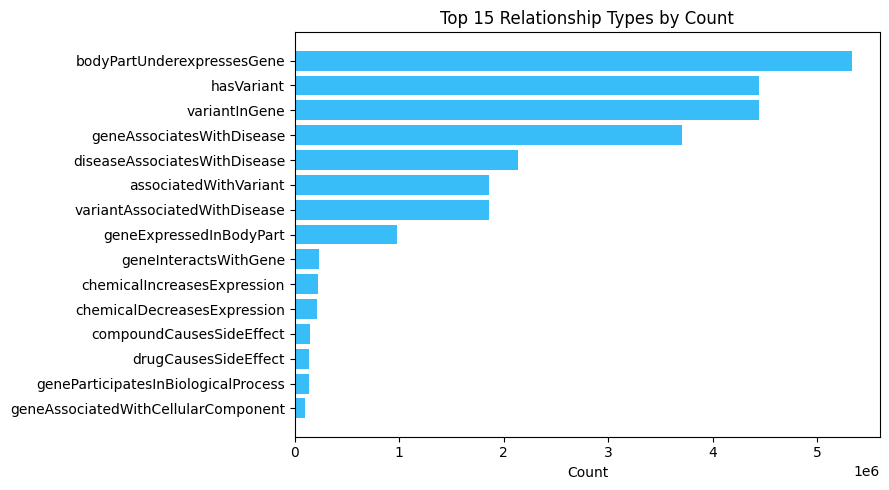

In [5]:
# Quick bar chart of top 15 relationship types for visualization
top15 = rel_counts.head(15).sort_values("Count")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15["RelType"], top15["Count"], color="#38bdf8")
ax.set_xlabel("Count")
ax.set_title("Top 15 Relationship Types by Count")
ax.ticklabel_format(axis="x", style="scientific", scilimits=(0, 0))
plt.tight_layout()
plt.show()

## 3. Assign Normalized Edge Weights

Seven data sources store numeric score properties on their relationships. Normalize each to a `weight` property in [0, 1] using source-specific rules. All remaining binary edges get a flat weight based on curation quality.

| Source | Raw Property | Normalization |
|--------|-------------|---------------|
| STRING | `combinedScore` (0–1000) | Divide by 1000 |
| OpenTargets | `score` (0–1) | Inherit directly |
| Jensen DISEASES | `confidence` | Min-max normalize |
| Jensen TISSUES | `confidence` | Min-max normalize |
| Bgee | `expressionScore` | Min-max normalize |
| LINCS L1000 | `zScore` | abs -> min-max normalize |
| DoRothEA | `confidence` (A–D) + `morScore` | Letter ->numeric × abs(normalized morScore) |
| Binary edges | — | 0.9 (DrugBank), 0.8 (other curated) |

**Note:** The OpenTargets config stores both `score` (0–1 overall association) and `evidenceCount` (integer). Use `score` as the 0–1 weight since `evidenceCount` is an unbounded integer.

In [ ]:
# 3a. STRING: combinedScore / 1000
run_query("""
    MATCH ()-[r:geneInteractsWithGene]->()
    WHERE r.source = 'STRING' AND r.combinedScore IS NOT NULL
    SET r.weight = toFloat(r.combinedScore) / 1000.0
    RETURN count(r) AS updated
""")

In [ ]:
# 3b. OpenTargets: score is already 0-1, inherit directly
run_query("""
    MATCH ()-[r:geneAssociatesWithDisease]->()
    WHERE r.source = 'OpenTargets' AND r.score IS NOT NULL
    SET r.weight = toFloat(r.score)
    RETURN count(r) AS updated
""")

In [ ]:
# 3c. Jensen DISEASES confidence: min-max normalize
# Step 1: read min/max (lightweight)
bounds = run_query("""
    MATCH ()-[r:geneAssociatesWithDisease]->()
    WHERE r.source = 'Jensen DISEASES' AND r.confidence IS NOT NULL
    RETURN min(toFloat(r.confidence)) AS minVal, max(toFloat(r.confidence)) AS maxVal
""")
minV, maxV = float(bounds["minVal"].iloc[0]), float(bounds["maxVal"].iloc[0])
print(f"Jensen DISEASES confidence range: [{minV}, {maxV}]")

# Step 2: update with precomputed bounds
run_query("""
    MATCH ()-[r:geneAssociatesWithDisease]->()
    WHERE r.source = 'Jensen DISEASES' AND r.confidence IS NOT NULL
    SET r.weight = CASE
        WHEN $maxV = $minV THEN 0.5
        ELSE (toFloat(r.confidence) - $minV) / ($maxV - $minV)
    END
    RETURN count(r) AS updated
""", minV=minV, maxV=maxV)

In [ ]:
# 3d. Jensen TISSUES confidence: min-max normalize
bounds = run_query("""
    MATCH ()-[r:geneExpressedInBodyPart]->()
    WHERE r.source = 'Jensen TISSUES' AND r.confidence IS NOT NULL
    RETURN min(toFloat(r.confidence)) AS minVal, max(toFloat(r.confidence)) AS maxVal
""")
minV, maxV = float(bounds["minVal"].iloc[0]), float(bounds["maxVal"].iloc[0])
print(f"Jensen TISSUES confidence range: [{minV}, {maxV}]")

run_query("""
    MATCH ()-[r:geneExpressedInBodyPart]->()
    WHERE r.source = 'Jensen TISSUES' AND r.confidence IS NOT NULL
    SET r.weight = CASE
        WHEN $maxV = $minV THEN 0.5
        ELSE (toFloat(r.confidence) - $minV) / ($maxV - $minV)
    END
    RETURN count(r) AS updated
""", minV=minV, maxV=maxV)

In [ ]:
# 3e. Bgee expressionScore: min-max normalize
bgee_check = run_query("""
    MATCH ()-[r]->()
    WHERE r.source = 'Bgee' AND r.expressionScore IS NOT NULL
    RETURN count(r) AS cnt
""")
bgee_has_score = int(bgee_check["cnt"].iloc[0]) > 0

if bgee_has_score:
    bounds = run_query("""
        MATCH ()-[r]->()
        WHERE r.source = 'Bgee' AND r.expressionScore IS NOT NULL
        RETURN min(toFloat(r.expressionScore)) AS minVal, max(toFloat(r.expressionScore)) AS maxVal
    """)
    minV, maxV = float(bounds["minVal"].iloc[0]), float(bounds["maxVal"].iloc[0])
    print(f"Bgee expressionScore range: [{minV}, {maxV}]")
    run_query("""
        MATCH ()-[r]->()
        WHERE r.source = 'Bgee' AND r.expressionScore IS NOT NULL
        SET r.weight = CASE
            WHEN $maxV = $minV THEN 0.5
            ELSE (toFloat(r.expressionScore) - $minV) / ($maxV - $minV)
        END
        RETURN count(r) AS updated
    """, minV=minV, maxV=maxV)
else:
    result = run_query("""
        MATCH ()-[r]->()
        WHERE r.source = 'Bgee' AND r.weight IS NULL
        SET r.weight = 0.8
        RETURN count(r) AS updated
    """)
    print(f"Bgee: expressionScore property not in graph, assigned flat weight 0.8 to {result['updated'].iloc[0]:,} edges")

In [ ]:
# 3f. LINCS L1000 zScore: abs value then min-max normalize
lincs_check = run_query("""
    MATCH ()-[r]->()
    WHERE r.source = 'LINCS L1000' AND r.zScore IS NOT NULL
    RETURN count(r) AS cnt
""")
lincs_has_score = int(lincs_check["cnt"].iloc[0]) > 0

if lincs_has_score:
    bounds = run_query("""
        MATCH ()-[r]->()
        WHERE r.source = 'LINCS L1000' AND r.zScore IS NOT NULL
        RETURN min(abs(toFloat(r.zScore))) AS minVal, max(abs(toFloat(r.zScore))) AS maxVal
    """)
    minV, maxV = float(bounds["minVal"].iloc[0]), float(bounds["maxVal"].iloc[0])
    print(f"LINCS L1000 abs(zScore) range: [{minV}, {maxV}]")
    run_query("""
        MATCH ()-[r]->()
        WHERE r.source = 'LINCS L1000' AND r.zScore IS NOT NULL
        SET r.weight = CASE
            WHEN $maxV = $minV THEN 0.5
            ELSE (abs(toFloat(r.zScore)) - $minV) / ($maxV - $minV)
        END
        RETURN count(r) AS updated
    """, minV=minV, maxV=maxV)
else:
    result = run_query("""
        MATCH ()-[r]->()
        WHERE r.source = 'LINCS L1000' AND r.weight IS NULL
        SET r.weight = 0.8
        RETURN count(r) AS updated
    """)
    print(f"LINCS L1000: zScore property not in graph, assigned flat weight 0.8 to {result['updated'].iloc[0]:,} edges")

In [ ]:
# 3g. DoRothEA: confidence letter to numeric, multiply by abs(normalized morScore)
dorothea_check = run_query("""
    MATCH ()-[r:transcriptionFactorInteractsWithGene]->()
    WHERE r.source = 'DoRothEA' AND r.morScore IS NOT NULL
    RETURN count(r) AS cnt
""")
dorothea_has_score = int(dorothea_check["cnt"].iloc[0]) > 0

if dorothea_has_score:
    bounds = run_query("""
        MATCH ()-[r:transcriptionFactorInteractsWithGene]->()
        WHERE r.source = 'DoRothEA' AND r.morScore IS NOT NULL
        RETURN min(abs(toFloat(r.morScore))) AS minMor, max(abs(toFloat(r.morScore))) AS maxMor
    """)
    minMor, maxMor = float(bounds["minMor"].iloc[0]), float(bounds["maxMor"].iloc[0])
    print(f"DoRothEA abs(morScore) range: [{minMor}, {maxMor}]")
    run_query("""
        MATCH ()-[r:transcriptionFactorInteractsWithGene]->()
        WHERE r.source = 'DoRothEA' AND r.morScore IS NOT NULL
        WITH r,
             CASE r.confidence
                 WHEN 'A' THEN 1.0  WHEN 'B' THEN 0.75
                 WHEN 'C' THEN 0.5  WHEN 'D' THEN 0.25
                 ELSE 0.25
             END AS letterWeight,
             CASE
                 WHEN $maxMor = $minMor THEN 0.5
                 ELSE (abs(toFloat(r.morScore)) - $minMor) / ($maxMor - $minMor)
             END AS normMor
        SET r.weight = letterWeight * normMor
        RETURN count(r) AS updated
    """, minMor=minMor, maxMor=maxMor)
else:
    result = run_query("""
        MATCH ()-[r]->()
        WHERE r.source = 'DoRothEA' AND r.weight IS NULL
        SET r.weight = 0.8
        RETURN count(r) AS updated
    """)
    print(f"DoRothEA: morScore property not in graph, assigned flat weight 0.8 to {result['updated'].iloc[0]:,} edges")

In [ ]:
# 3h. Binary edges: flat weight by source
# DrugBank: 0.9, all other sources without an existing weight: 0.8

unweighted = run_query("""
    MATCH ()-[r]->()
    WHERE r.weight IS NULL AND r.source IS NOT NULL
    RETURN DISTINCT r.source AS source
""")

if unweighted.empty:
    print("All edges already have weights assigned, nothing to update.")
else:
    drugbank_total, other_total = 0, 0
    for src in unweighted["source"]:
        weight = 0.9 if src == "DrugBank" else 0.8
        result = run_query("""
            MATCH ()-[r]->()
            WHERE r.source = $src AND r.weight IS NULL
            SET r.weight = $weight
            RETURN count(r) AS updated
        """, src=src, weight=weight)
        cnt = int(result["updated"].iloc[0])
        if src == "DrugBank":
            drugbank_total = cnt
        else:
            other_total += cnt
        if cnt > 0:
            print(f"  {src}: {cnt:,} edges : weight {weight}")

    print(f"\nDrugBank binary edges weighted (0.9): {drugbank_total:,}")
    print(f"Other binary edges weighted (0.8):    {other_total:,}")

## 4. Verify Weights Were Assigned

Sample edges from each weighted source to confirm the `weight` property landed correctly.

In [14]:
# Check weight coverage: how many edges per source now have a weight?
weight_coverage = run_query("""
    MATCH ()-[r]->()
    WHERE r.source IS NOT NULL
    WITH r.source AS source,
         count(r) AS total,
         count(r.weight) AS weighted
    RETURN source AS Source, total AS TotalEdges, weighted AS WithWeight,
           round(100.0 * weighted / total, 1) AS PctWeighted
    ORDER BY TotalEdges DESC
""")

print(weight_coverage.to_string(index=False))

            Source  TotalEdges  WithWeight  PctWeighted
           ClinVar    12603856    12603856        100.0
              Bgee     5338782     5338782        100.0
          PubTator     3387851     3387851        100.0
       OpenTargets     2364224     2364224        100.0
    Jensen TISSUES      982039      982039        100.0
               CTD      431721      431721        100.0
     Gene Ontology      322707      322707        100.0
            STRING      229433      229433        100.0
             SIDER      148518      148518        100.0
          Hetionet      143767      143767        100.0
              HGNC       68012       68012        100.0
      GWAS Catalog       45529       45529        100.0
            AOP-DB       37004       37004        100.0
       DrugCentral       34424       34424        100.0
          Reactome       32634       32634        100.0
               HPO       30488       30488        100.0
   Jensen DISEASES       20561       20561      

In [15]:
# Sample 3 edges from each of the 7 scored sources + DrugBank + one other
sample_sources = [
    "STRING", "OpenTargets", "Jensen DISEASES", "Jensen TISSUES",
    "Bgee", "LINCS L1000", "DoRothEA", "DrugBank", "Reactome"
]

samples = []
for src in sample_sources:
    df = run_query("""
        MATCH (a)-[r]->(b)
        WHERE r.source = $src AND r.weight IS NOT NULL
        RETURN a.geneSymbol AS fromNode,
               type(r) AS relType,
               coalesce(b.commonName, b.geneSymbol) AS toNode,
               r.source AS source,
               round(r.weight, 4) AS weight
        LIMIT 3
    """, src=src)
    samples.append(df)

sample_df = pd.concat(samples, ignore_index=True)
print(sample_df.to_string(index=False))

fromNode                              relType                                         toNode          source  weight
    A1BG                geneInteractsWithGene                        alpha 2-HS glycoprotein          STRING  0.8490
    A1BG                geneInteractsWithGene        alpha-1-microglobulin/bikunin precursor          STRING  0.7160
    A1BG                geneInteractsWithGene            CRK proto-oncogene, adaptor protein          STRING  0.7450
    A1BG            geneAssociatesWithDisease                  idiopathic pulmonary fibrosis     OpenTargets  0.0022
    A1BG            geneAssociatesWithDisease                         restless legs syndrome     OpenTargets  0.0015
    A1BG            geneAssociatesWithDisease                         pachyonychia congenita     OpenTargets  0.0015
    NAT2            geneAssociatesWithDisease                   distal 10q deletion syndrome Jensen DISEASES  1.0000
    NAT2            geneAssociatesWithDisease                   

In [16]:
# Weight distribution summary for the 7 scored sources
weight_stats = run_query("""
    MATCH ()-[r]->()
    WHERE r.source IN ['STRING', 'OpenTargets', 'Jensen DISEASES',
                       'Jensen TISSUES', 'Bgee', 'LINCS L1000', 'DoRothEA']
      AND r.weight IS NOT NULL
    RETURN r.source AS Source,
           round(min(r.weight), 4) AS MinWeight,
           round(avg(r.weight), 4) AS MeanWeight,
           round(max(r.weight), 4) AS MaxWeight,
           count(r) AS EdgeCount
    ORDER BY EdgeCount DESC
""")

print(weight_stats.to_string(index=False))

         Source  MinWeight  MeanWeight  MaxWeight  EdgeCount
           Bgee     0.0000      0.6710     1.0000    5338782
    OpenTargets     0.0008      0.0422     0.9134    2364224
 Jensen TISSUES     0.0000      0.2135     1.0000     982039
         STRING     0.7000      0.8622     0.9990     229433
Jensen DISEASES     0.0000      0.1919     1.0000      20561
    LINCS L1000     0.0000      0.0210     1.0000      16713
       DoRothEA     0.0000      0.3446     1.0000      15092


## 5. Link Prediction: Common Neighbors

**Common Neighbors (CN)** is the simplest topological link predictor: for a gene $g$ and a disease $d$, the score is the number of nodes that are neighbors of both $g$ and $d$.

$$\text{CN}(g, d) = |\Gamma(g) \cap \Gamma(d)|$$

Compute CN for **SCN5A** (sodium voltage-gated channel alpha subunit 5, a key cardiac arrhythmia gene) against **all Disease nodes** it is not already directly connected to, routing through **Gene intermediaries** for tractability. Top 10 results are returned.

In [17]:
# First verify SCN5A exists and see its current connections
scn5a_info = run_query("""
    MATCH (g:Gene {geneSymbol: 'SCN5A'})
    OPTIONAL MATCH (g)-[r]-()
    RETURN g.geneSymbol AS gene, g.commonName AS name,
           count(r) AS totalEdges
""")
print("SCN5A node info:")
print(scn5a_info.to_string(index=False))

SCN5A node info:
 gene                                         name  totalEdges
SCN5A sodium voltage-gated channel alpha subunit 5       10944


In [18]:
# Load CVD disease filter terms and build word-boundary regex patterns
# Using \b word boundaries prevents short abbreviations (MI, STEMI, CAD, TIA, etc.)
# from matching as substrings inside unrelated disease names (e.g. "MI" in "Miyoshi")
import re

cvd_terms = []
for line in Path("../ontology/diseases/cvd.txt").read_text().splitlines():
    line = line.strip()
    if line and not line.startswith("#"):
        cvd_terms.append(line)
print(f"Loaded {len(cvd_terms)} CVD filter terms")

# Build a single regex: (?i)\b(term1|term2|...)\b
# Escape any regex-special characters in terms, then join with |
escaped = [re.escape(t) for t in cvd_terms]
cvd_regex = "(?i).*\\b(" + "|".join(escaped) + ")\\b.*"

# Common Neighbors: SCN5A vs CVD Disease nodes only (excluding existing direct links)
# Route through Gene intermediaries for tractability.
# Use regex word-boundary matching so "MI" matches "MI" but not "Miyoshi".
cn_results = run_query("""
    MATCH (g:Gene {geneSymbol: 'SCN5A'})--(neighbor:Gene)--(d:Disease)
    WHERE NOT (g)--(d)
      AND neighbor <> g
      AND d.commonName =~ $cvd_regex
    WITH d, count(DISTINCT neighbor) AS commonNeighbors
    RETURN d.commonName AS Disease,
           d.xrefDiseaseOntology AS DOID,
           commonNeighbors AS CN_Score
    ORDER BY CN_Score DESC
    LIMIT 10
""", cvd_regex=cvd_regex)

print("Top 10 Common Neighbors predictions for SCN5A to Disease (CVD only):")
print(cn_results.to_string(index=False))

Loaded 90 CVD filter terms


Top 10 Common Neighbors predictions for SCN5A to Disease (CVD only):
                    Disease         DOID  CN_Score
    cerebrovascular disease    DOID:6713        22
     essential hypertension   DOID:10825        19
  peripheral artery disease DOID:0050830        14
     systolic heart failure    DOID:9651        10
  abdominal aortic aneurysm    DOID:7693         9
    rheumatic heart disease DOID:0050827         9
     autoimmune myocarditis DOID:0080767         8
        ocular hypertension    DOID:9282         8
 hypertensive heart disease   DOID:11516         7
peripheral vascular disease     DOID:341         7


## 6. Link Prediction: Weighted Adamic-Adar

**Adamic-Adar (AA)** improves on Common Neighbors by weighting each shared neighbor inversely by its degree (rare shared neighbors are more informative).

$$\text{AA}(g, d) = \sum_{z \in \Gamma(g) \cap \Gamma(d)} \frac{1}{\log(|\Gamma(z)|)}$$

The **weighted** variant multiplies each term by the mean edge weight on the paths through that neighbor:

$$\text{WAA}(g, d) = \sum_{z \in \Gamma(g) \cap \Gamma(d)} \frac{w(g,z) \cdot w(z,d)}{\log(|\Gamma(z)|)}$$

Restrict the disease targets to **arrhythmia-related diseases** to focus the prediction.

In [19]:
# Weighted Adamic-Adar: SCN5A vs arrhythmia Disease nodes
# Route through Gene intermediaries and use specific relationship types for efficiency.
# Per shared neighbor z, take max(weight) on each side to avoid inflating scores
# from parallel edges, and use count(DISTINCT neighbor) for the degree term |Γ(z)|.
waa_results = run_query("""
    MATCH (g:Gene {geneSymbol: 'SCN5A'})-[r1]-(z:Gene)-[r2:geneAssociatesWithDisease]-(d:Disease)
    WHERE NOT (g)--(d)
      AND z <> g
      AND toLower(d.commonName) CONTAINS 'arrhythm'
    WITH d, z, max(coalesce(r1.weight, 0.8)) AS w1, max(coalesce(r2.weight, 0.8)) AS w2
    MATCH (z)--(neighbor)
    WITH d, z, w1, w2, count(DISTINCT neighbor) AS zDegree
    WHERE zDegree > 1
    WITH d,
         sum( (w1 * w2) / log(toFloat(zDegree)) ) AS WAA_Score,
         count(DISTINCT z) AS SharedNeighbors
    RETURN d.commonName AS Disease,
           d.xrefDiseaseOntology AS DOID,
           round(WAA_Score, 4) AS WAA_Score,
           SharedNeighbors
    ORDER BY WAA_Score DESC
    LIMIT 10
""")

print("Top 10 Weighted Adamic-Adar predictions (SCN5A to arrhythmia diseases):")
print(waa_results.to_string(index=False))

Top 10 Weighted Adamic-Adar predictions (SCN5A to arrhythmia diseases):
                                                                                      Disease         DOID  WAA_Score  SharedNeighbors
                                               arrhythmogenic left ventricular cardiomyopathy DOID:0070534     0.1161                3
                                                  arrhythmogenic biventricular cardiomyopathy DOID:0070535     0.1161                3
                                                         ankyrin-B-related cardiac arrhythmia DOID:0111700     0.1043                1
                                                 Arrhythmogenic right ventricular dysplasia 9         None     0.0981                1
                                                Arrhythmogenic right ventricular dysplasia 10         None     0.0768                1
Ventricular arrhythmias due to cardiac ryanodine receptor calcium release deficiency syndrome         None     0.0764 

## 7. Does Long QT Syndrome Appear?

SCN5A mutations are a well-known cause of **Long QT Syndrome type 3 (LQT3)**. If the link prediction is working, LQT-related diseases should appear in the top results, either as a direct hit or via broader arrhythmia associations.

Check both result sets.

In [20]:
# Check Common Neighbors results for Long QT
lqt_in_cn = cn_results[cn_results["Disease"].str.contains("long qt", case=False, na=False)]

# Check Weighted AA results for Long QT
lqt_in_waa = waa_results[waa_results["Disease"].str.contains("long qt", case=False, na=False)]

print("Long QT Syndrome in Common Neighbors top 10:")
if len(lqt_in_cn) > 0:
    print(f"  YES, found at rank {lqt_in_cn.index[0] + 1}")
    print(f"  Disease: {lqt_in_cn.iloc[0]['Disease']}")
    print(f"  Score:   {lqt_in_cn.iloc[0]['CN_Score']}")
else:
    print("  Not in top 10 (may already be directly linked to SCN5A)")

print()
print("Long QT Syndrome in Weighted Adamic-Adar top 10:")
if len(lqt_in_waa) > 0:
    print(f"  YES — found at rank {lqt_in_waa.index[0] + 1}")
    print(f"  Disease: {lqt_in_waa.iloc[0]['Disease']}")
    print(f"  Score:   {lqt_in_waa.iloc[0]['WAA_Score']}")
else:
    print("  Not in top 10 (may already be directly linked to SCN5A)")


# Also check: is Long QT already directly linked?
direct_lqt = run_query("""
    MATCH (g:Gene {geneSymbol: 'SCN5A'})-[r]-(d:Disease)
    WHERE toLower(d.commonName) CONTAINS 'long qt'
    RETURN d.commonName AS Disease, type(r) AS RelType, r.source AS Source
""")
if len(direct_lqt) > 0:
    print("\nNote: Long QT IS already directly linked to SCN5A (excluded from predictions):")
    print(direct_lqt.to_string(index=False))
else:
    print("\nLong QT is NOT directly linked to SCN5A, it should appear in predictions.")

Long QT Syndrome in Common Neighbors top 10:
  Not in top 10 (may already be directly linked to SCN5A)

Long QT Syndrome in Weighted Adamic-Adar top 10:
  Not in top 10 (may already be directly linked to SCN5A)

Note: Long QT IS already directly linked to SCN5A (excluded from predictions):
            Disease                   RelType      Source
 Long QT syndrome 3 geneAssociatesWithDisease        OMIM
long QT syndrome 16 geneAssociatesWithDisease OpenTargets
 long QT syndrome 1 geneAssociatesWithDisease OpenTargets
 long QT syndrome 3 geneAssociatesWithDisease OpenTargets
 long QT syndrome 5 geneAssociatesWithDisease OpenTargets
 long QT syndrome 8 geneAssociatesWithDisease OpenTargets
 long QT syndrome 9 geneAssociatesWithDisease OpenTargets
long QT syndrome 10 geneAssociatesWithDisease OpenTargets
long QT syndrome 11 geneAssociatesWithDisease OpenTargets
long QT syndrome 12 geneAssociatesWithDisease OpenTargets
long QT syndrome 13 geneAssociatesWithDisease OpenTargets
long QT syndr

### SCN5A and Long QT Syndrome: Existing Edges

Since Long QT Syndrome is excluded from link predictions (it's already directly connected), inspect all existing edges between SCN5A and LQT variants in the graph to confirm which sources contributed this known relationship.

In [21]:
# All edges between SCN5A and Long QT Syndrome variants
scn5a_lqt = run_query("""
    MATCH (g:Gene {geneSymbol: 'SCN5A'})-[r]-(d:Disease)
    WHERE toLower(d.commonName) CONTAINS 'long qt'
    RETURN d.commonName AS Disease,
           d.xrefDiseaseOntology AS DOID,
           type(r) AS RelationshipType,
           r.source AS Source,
           round(coalesce(r.weight, 0.0), 4) AS Weight
    ORDER BY d.commonName, r.source
""")

print(f"Total SCN5A to Long QT edges: {len(scn5a_lqt)}")
print(f"Distinct LQT diseases: {scn5a_lqt['Disease'].nunique()}")
print(f"Contributing sources: {sorted(scn5a_lqt['Source'].unique())}")
print()
print(scn5a_lqt.to_string(index=False))

Total SCN5A to Long QT edges: 14
Distinct LQT diseases: 14
Contributing sources: ['OMIM', 'OpenTargets']

            Disease         DOID          RelationshipType      Source  Weight
 Long QT syndrome 3         None geneAssociatesWithDisease        OMIM  0.8000
   long QT syndrome    DOID:2843 geneAssociatesWithDisease OpenTargets  0.6714
 long QT syndrome 1 DOID:0110644 geneAssociatesWithDisease OpenTargets  0.4311
long QT syndrome 10 DOID:0110651 geneAssociatesWithDisease OpenTargets  0.1004
long QT syndrome 11 DOID:0110652 geneAssociatesWithDisease OpenTargets  0.1052
long QT syndrome 12 DOID:0110653 geneAssociatesWithDisease OpenTargets  0.0930
long QT syndrome 13 DOID:0110654 geneAssociatesWithDisease OpenTargets  0.0972
long QT syndrome 14 DOID:0110655 geneAssociatesWithDisease OpenTargets  0.0969
long QT syndrome 15 DOID:0110656 geneAssociatesWithDisease OpenTargets  0.0951
long QT syndrome 16 DOID:0070533 geneAssociatesWithDisease OpenTargets  0.0902
 long QT syndrome 3 DOID:

## 8. Top 10 Predicted Gene-Disease Links for Atrial Fibrillation

Finally, flip the perspective: given the disease **atrial fibrillation**, which genes are most likely to have a (currently missing) association? Use the same Weighted Adamic-Adar approach, now anchored on the disease node.

In [22]:
# Find the atrial fibrillation node
afib_check = run_query("""
    MATCH (d:Disease)
    WHERE toLower(d.commonName) CONTAINS 'atrial fibrillation'
    RETURN d.commonName AS Disease, d.xrefDiseaseOntology AS DOID
    LIMIT 5
""")
print("Atrial fibrillation nodes in the graph:")
print(afib_check.to_string(index=False))

Atrial fibrillation nodes in the graph:
                          Disease DOID
           Atrial fibrillation 15 None
Atrial fibrillation, familial, 12 None
Atrial fibrillation, familial, 18 None
Atrial fibrillation, familial, 10 None
Atrial fibrillation, familial, 11 None


In [23]:
# Weighted Adamic-Adar: Atrial Fibrillation to Gene predictions
# Same corrected approach: max weight per (z, direction) to handle parallel edges,
# count(DISTINCT neighbor) for degree.

afib_predictions = run_query("""
    MATCH (d:Disease)-[r2:geneAssociatesWithDisease]-(z:Gene)-[r1]-(g:Gene)
    WHERE toLower(d.commonName) = 'atrial fibrillation'
      AND NOT (d)--(g)
      AND z <> g
    WITH g, z, max(coalesce(r1.weight, 0.8)) AS w1, max(coalesce(r2.weight, 0.8)) AS w2
    MATCH (z)--(neighbor)
    WITH g, z, w1, w2, count(DISTINCT neighbor) AS zDegree
    WHERE zDegree > 1
    WITH g,
         sum( (w1 * w2) / log(toFloat(zDegree)) ) AS WAA_Score,
         count(DISTINCT z) AS SharedNeighbors
    RETURN g.geneSymbol AS Gene,
           g.commonName AS GeneName,
           round(WAA_Score, 4) AS WAA_Score,
           SharedNeighbors
    ORDER BY WAA_Score DESC
    LIMIT 10
""")

print("Top 10 Predicted Gene-Disease Links for Atrial Fibrillation")
print("(Weighted Adamic-Adar, genes not already linked)")
print()
print(afib_predictions.to_string(index=False))

Top 10 Predicted Gene-Disease Links for Atrial Fibrillation
(Weighted Adamic-Adar, genes not already linked)

  Gene                                              GeneName  WAA_Score  SharedNeighbors
   FAU   FAU ubiquitin like and ribosomal protein S30 fusion     3.0030              142
PRKACG protein kinase cAMP-activated catalytic subunit gamma     2.8683              166
PRKACB  protein kinase cAMP-activated catalytic subunit beta     2.8668              174
CALML5                                     calmodulin like 5     2.4763              169
CALML3                                     calmodulin like 3     2.4206              167
CALML4                                     calmodulin like 4     2.2527              160
CALML6                                     calmodulin like 6     2.2079              157
 H3C13                               H3 clustered histone 13     2.0415              215
 H3-3B                                        H3.3 histone B     1.8585              188


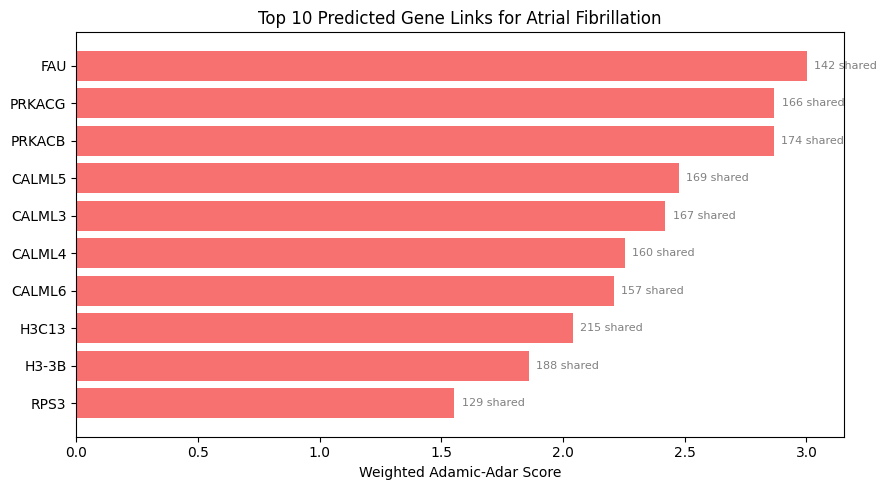

In [24]:
# Visualization: top 10 predicted genes for atrial fibrillation
if len(afib_predictions) > 0:
    plot_df = afib_predictions.sort_values("WAA_Score")

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(plot_df["Gene"], plot_df["WAA_Score"], color="#f87171")
    ax.set_xlabel("Weighted Adamic-Adar Score")
    ax.set_title("Top 10 Predicted Gene Links for Atrial Fibrillation")

    # Annotate shared neighbor counts
    for bar, sn in zip(bars, plot_df["SharedNeighbors"]):
        ax.text(bar.get_width() + 0.01 * plot_df["WAA_Score"].max(),
                bar.get_y() + bar.get_height() / 2,
                f"{sn} shared", va="center", fontsize=8, color="gray")

    plt.tight_layout()
    plt.show()
else:
    print("No predictions returned, check that 'atrial fibrillation' exists as an exact Disease commonName.")

## Summary

| Step | What we did |
|------|------------|
| **Graph stats** | Queried live node/relationship counts from Neo4j |
| **Edge weighting** | Normalized all edges to a `weight` ∈ [0, 1] using source-specific rules (real scores for Bgee, LINCS, DoRothEA, STRING, OpenTargets, Jensen) |
| **Common Neighbors** | Identified top 10 diseases topologically close to SCN5A |
| **Weighted Adamic-Adar** | Scored SCN5A to arrhythmia links using edge weights and neighbor rarity |
| **Validation** | Checked whether Long QT Syndrome (a known SCN5A association) surfaces |
| **AF predictions** | Produced a ranked list of 10 novel gene candidates for atrial fibrillation |

These link prediction scores can serve as features for downstream ML models or as a prioritization tool for wet-lab validation.

In [25]:
# Cleanup
driver.close()
print("Neo4j connection closed.")

Neo4j connection closed.
